# Анализ экспериментов музейного комплекса

Загрузка и визуализация результатов серии экспериментов из `results.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('results.csv')
print(f'Загружено {len(df)} экспериментов')
df.head()

Загружено 324 экспериментов


,museumCapacity,hotelCapacity,ticketPrice,hotelPrice,monthlyExpenditures,numVisitors,maxDays,totalVisits,totalHotelStays,totalRefusals,...,finalWear,finalAttractiveness,finalBudget,finalMobileNetwork,finalPaymentSystem,finalTransportAccess,finalInternetQuality,finalNavigationAccess,finalServiceAvailability,finalAvgReview
0,10,3,20,30,5000,65,365,993,286,22732,...,45.62,15.57,-26560.0,35.12,35.12,39.05,39.05,39.05,39.05,12.32
1,10,3,20,30,5000,65,365,995,297,22730,...,33.03,20.26,-26190.0,35.07,35.07,39.05,39.05,39.05,39.05,14.33
2,10,3,20,30,5000,65,365,1002,280,22723,...,35.25,21.19,-26560.0,34.97,34.97,39.05,39.05,39.05,39.05,23.04
3,10,3,20,30,5000,65,730,1183,362,46267,...,82.36,0.52,-80480.0,32.25,32.25,28.10,28.10,28.10,28.10,0.00
4,10,3,20,30,5000,65,730,1138,351,46312,...,82.42,0.08,-81710.0,32.93,32.93,28.10,28.10,28.10,28.10,0.00


In [2]:
df.describe().round(2)

,museumCapacity,hotelCapacity,ticketPrice,hotelPrice,monthlyExpenditures,numVisitors,maxDays,totalVisits,totalHotelStays,totalRefusals,...,finalWear,finalAttractiveness,finalBudget,finalMobileNetwork,finalPaymentSystem,finalTransportAccess,finalInternetQuality,finalNavigationAccess,finalServiceAvailability,finalAvgReview
count,324.00,324.00,324.00,324.00,324.0,324.0,324.00,324.00,324.00,324.00,...,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00
mean,15.00,5.00,33.33,40.00,5000.0,65.0,547.50,2360.08,663.54,33227.42,...,46.33,27.82,26863.75,47.83,47.76,47.46,47.46,47.46,47.46,27.56
std,4.09,1.64,12.49,10.02,0.0,0.0,182.78,1777.64,482.58,11356.75,...,24.48,23.39,98975.01,13.37,13.29,17.67,17.67,17.67,17.67,23.86
min,10.00,3.00,20.00,30.00,5000.0,65.0,365.00,914.00,257.00,20186.00,...,19.45,0.02,-82900.00,30.62,30.62,28.10,28.10,28.10,28.10,0.00
25%,10.00,3.00,20.00,30.00,5000.0,65.0,365.00,1112.50,332.00,22600.00,...,24.63,1.06,-60915.00,36.73,36.73,28.10,28.10,28.10,28.10,0.00
50%,15.00,5.00,30.00,40.00,5000.0,65.0,547.50,1326.00,392.00,31896.00,...,38.30,20.56,-14615.00,40.36,40.36,39.05,39.05,39.05,39.05,21.62
75%,20.00,7.00,50.00,50.00,5000.0,65.0,730.00,2961.50,810.50,46069.75,...,73.60,54.40,99247.50,62.29,62.23,68.10,68.10,68.10,68.10,54.06
max,20.00,7.00,50.00,50.00,5000.0,65.0,730.00,6469.00,1905.00,46357.00,...,97.49,59.33,270040.00,69.50,69.41,69.05,69.05,69.05,69.05,62.56


## 1. Доля экспериментов с положительным бюджетом

Положительный бюджет: 129/324 (39.8%)
Отрицательный бюджет: 195/324 (60.2%)
Средний итоговый бюджет: 26864
Медиана итогового бюджета: -14615


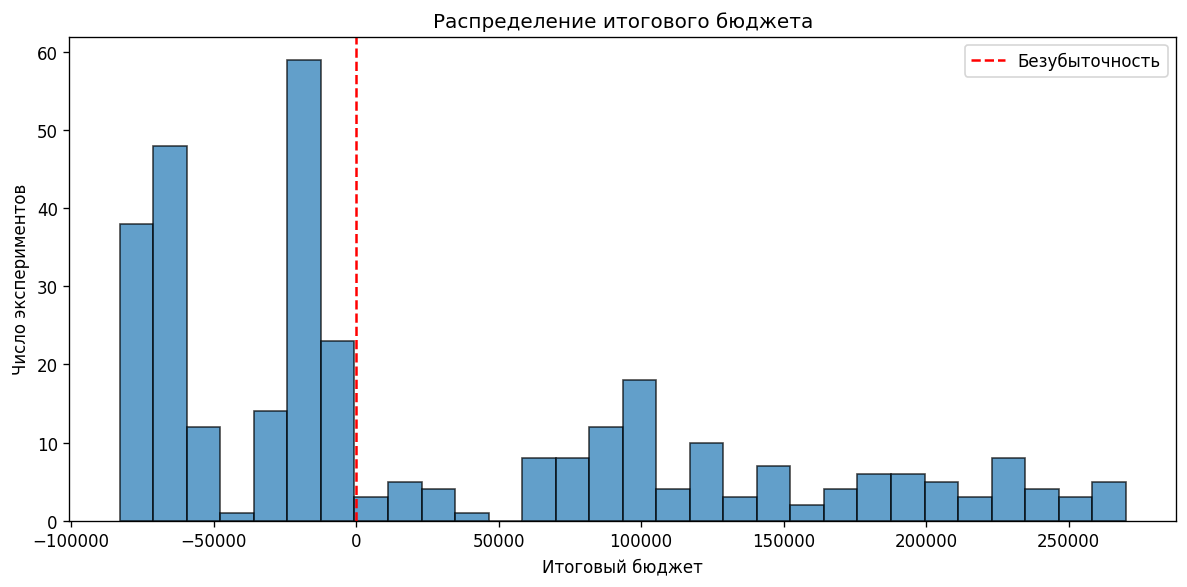

In [3]:
positive = (df['finalBudget'] > 0).sum()
total = len(df)
print(f'Положительный бюджет: {positive}/{total} ({positive/total*100:.1f}%)')
print(f'Отрицательный бюджет: {total - positive}/{total} ({(total-positive)/total*100:.1f}%)')
print(f'Средний итоговый бюджет: {df["finalBudget"].mean():.0f}')
print(f'Медиана итогового бюджета: {df["finalBudget"].median():.0f}')

fig, ax = plt.subplots()
ax.hist(df['finalBudget'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', label='Безубыточность')
ax.set_xlabel('Итоговый бюджет')
ax.set_ylabel('Число экспериментов')
ax.set_title('Распределение итогового бюджета')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Влияние цены билета на бюджет и посещаемость

             avgBudget  avgVisits  avgReview  positivePct
ticketPrice                                              
20            -47693.1     1173.4        9.1          0.0
30            -21929.5     1607.7       18.6         19.4
50            150213.9     4299.2       55.0        100.0


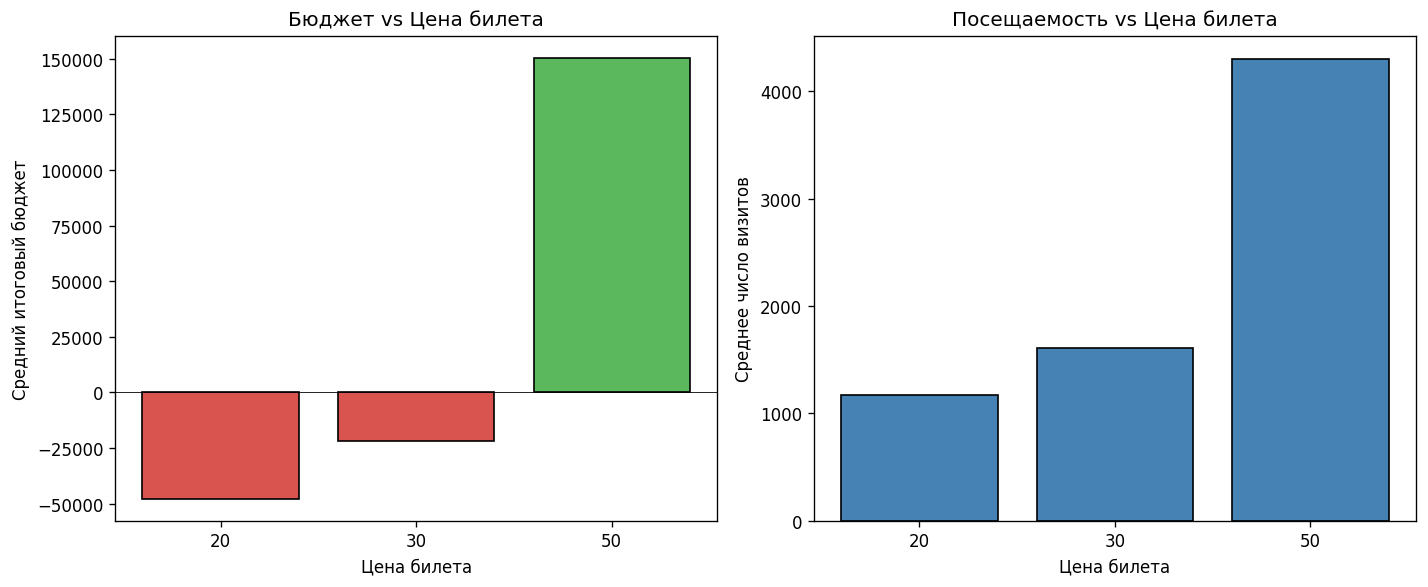

In [4]:
grouped = df.groupby('ticketPrice').agg(
    avgBudget=('finalBudget', 'mean'),
    avgVisits=('totalVisits', 'mean'),
    avgReview=('finalAvgReview', 'mean'),
    positivePct=('finalBudget', lambda x: (x > 0).mean() * 100)
).round(1)
print(grouped)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(grouped.index.astype(str), grouped['avgBudget'], color=['#d9534f' if v < 0 else '#5cb85c' for v in grouped['avgBudget']], edgecolor='black')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Цена билета')
axes[0].set_ylabel('Средний итоговый бюджет')
axes[0].set_title('Бюджет vs Цена билета')

axes[1].bar(grouped.index.astype(str), grouped['avgVisits'], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Цена билета')
axes[1].set_ylabel('Среднее число визитов')
axes[1].set_title('Посещаемость vs Цена билета')

plt.tight_layout()
plt.show()

## 3. Влияние вместимости музея на доход и отказы

                avgBudget  avgVisits  avgRefusals  avgWear
museumCapacity                                            
10                10408.9     2014.9      33572.6     48.1
15                30320.4     2421.5      33166.0     46.5
20                39861.9     2643.9      32943.6     44.4


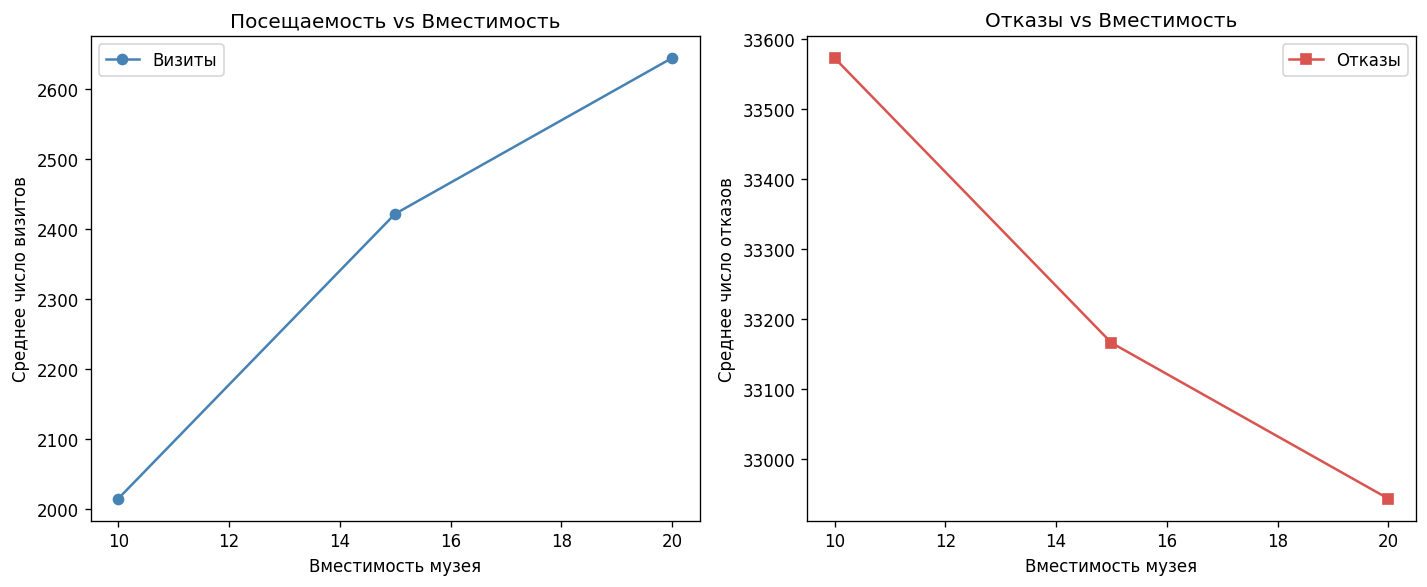

In [5]:
grouped_cap = df.groupby('museumCapacity').agg(
    avgBudget=('finalBudget', 'mean'),
    avgVisits=('totalVisits', 'mean'),
    avgRefusals=('totalRefusals', 'mean'),
    avgWear=('finalWear', 'mean')
).round(1)
print(grouped_cap)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(grouped_cap.index, grouped_cap['avgVisits'], 'o-', label='Визиты', color='steelblue')
axes[0].set_xlabel('Вместимость музея')
axes[0].set_ylabel('Среднее число визитов')
axes[0].set_title('Посещаемость vs Вместимость')
axes[0].legend()

axes[1].plot(grouped_cap.index, grouped_cap['avgRefusals'], 's-', label='Отказы', color='#d9534f')
axes[1].set_xlabel('Вместимость музея')
axes[1].set_ylabel('Среднее число отказов')
axes[1].set_title('Отказы vs Вместимость')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Матрица корреляций ключевых метрик

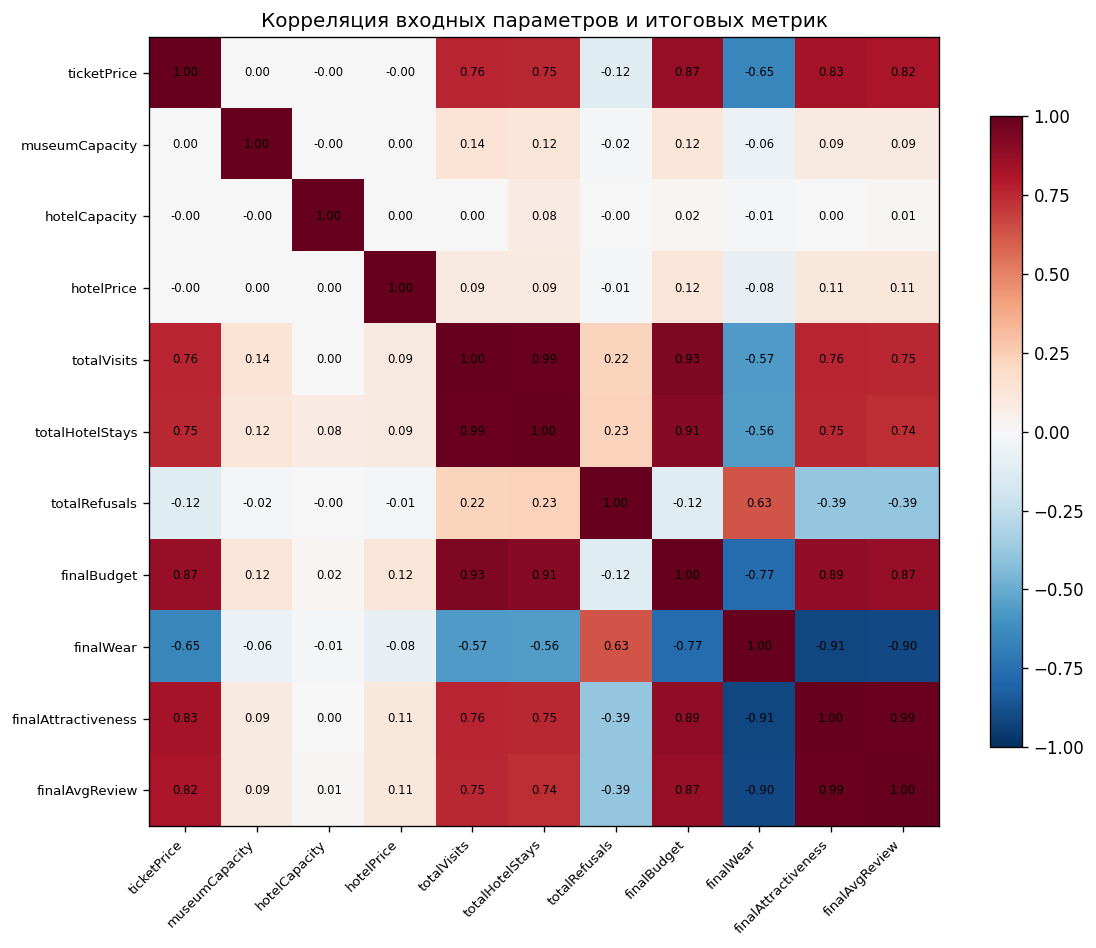

In [6]:
cols = ['ticketPrice', 'museumCapacity', 'hotelCapacity', 'hotelPrice',
        'totalVisits', 'totalHotelStays', 'totalRefusals',
        'finalBudget', 'finalWear', 'finalAttractiveness', 'finalAvgReview']
corr = df[cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(cols, fontsize=8)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Корреляция входных параметров и итоговых метрик')
plt.tight_layout()
plt.show()

## 5. Scatter: Визиты vs Итоговый бюджет (по цене билета)

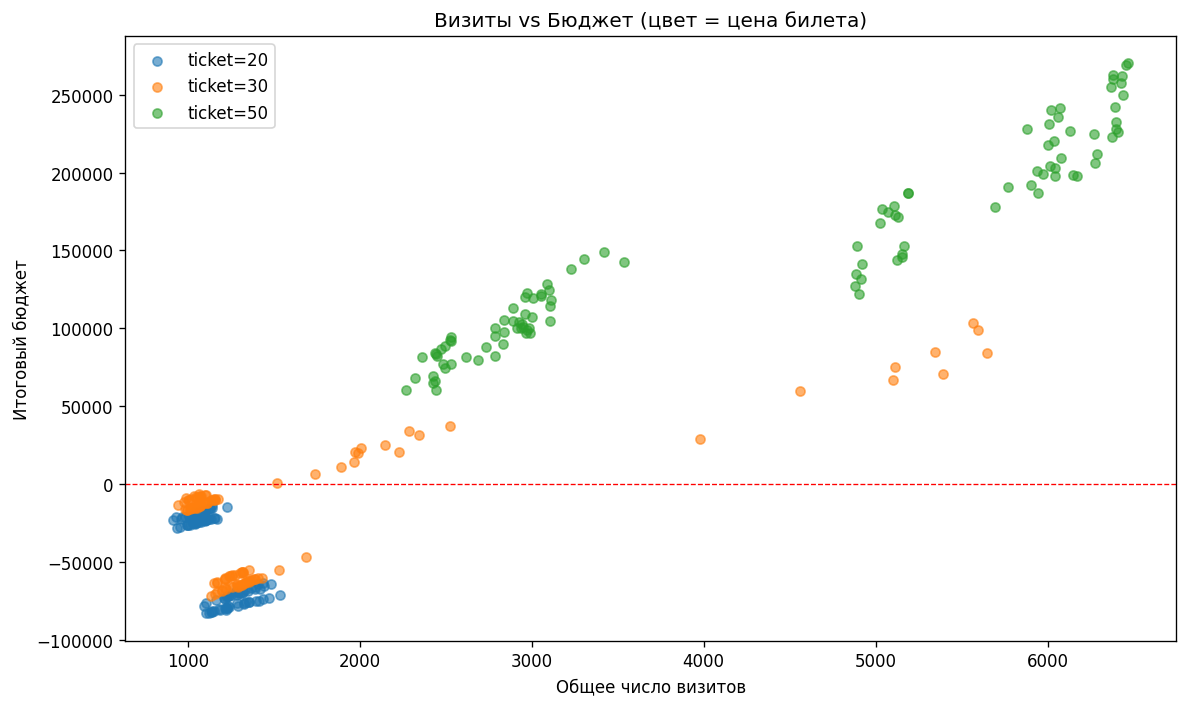

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for price, grp in df.groupby('ticketPrice'):
    ax.scatter(grp['totalVisits'], grp['finalBudget'], label=f'ticket={price}', alpha=0.6, s=30)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Общее число визитов')
ax.set_ylabel('Итоговый бюджет')
ax.set_title('Визиты vs Бюджет (цвет = цена билета)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Boxplot: итоговый бюджет по комбинации (ticketPrice x hotelPrice)

/var/folders/4j/sxql7z6j007czwcf5zkcl4gh0000gn/T/ipykernel_44218/4188328468.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=combos_sorted, patch_artist=True)


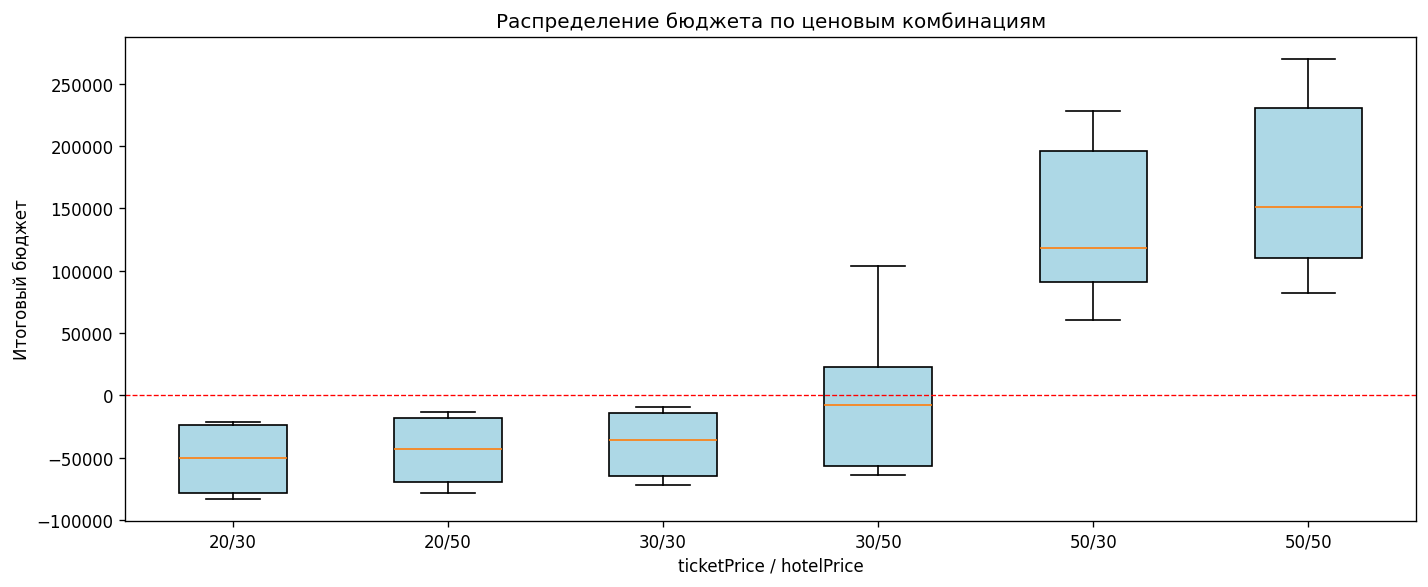

In [8]:
df['price_combo'] = df['ticketPrice'].astype(str) + '/' + df['hotelPrice'].astype(str)
combos_sorted = sorted(df['price_combo'].unique(), key=lambda x: (int(x.split('/')[0]), int(x.split('/')[1])))

fig, ax = plt.subplots(figsize=(12, 5))
data_groups = [df[df['price_combo'] == c]['finalBudget'].values for c in combos_sorted]
bp = ax.boxplot(data_groups, labels=combos_sorted, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('ticketPrice / hotelPrice')
ax.set_ylabel('Итоговый бюджет')
ax.set_title('Распределение бюджета по ценовым комбинациям')
plt.tight_layout()
plt.show()

df.drop(columns=['price_combo'], inplace=True)